In [23]:
import math
from poisson_process import CompoundPoisson, CramerLundberg, MixtureDistribution, NonHomogeneousPoissonProcess
from poisson_process import PoissonProcess1, PoissonProcess2, PoissonProcess3
from poisson_process import torch, plt , quad,norm
from tqdm import tqdm

Simulando trayectorias: 100%|██████████| 100/100 [00:00<00:00, 1026.47it/s]


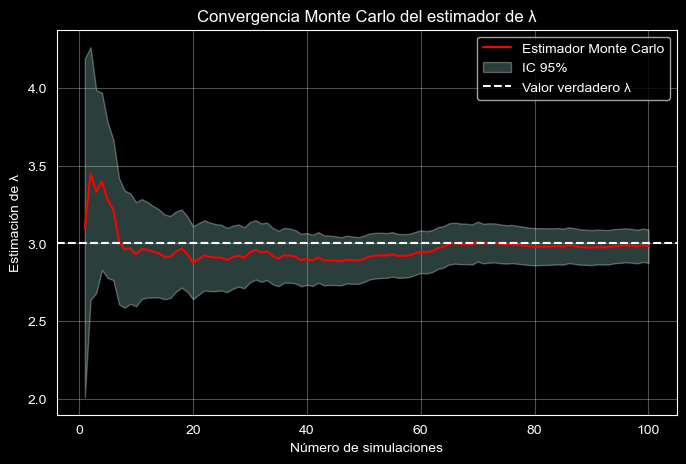

In [2]:
# Parámetros
t = 10.0
lam = 3.0

poi_pro = PoissonProcess3(lam)
lam_hat , lower, upper = poi_pro.monte_carlo_lambda(t, n_sim=100)

Simulando trayectorias: 100%|██████████| 10000/10000 [00:01<00:00, 5195.07it/s]


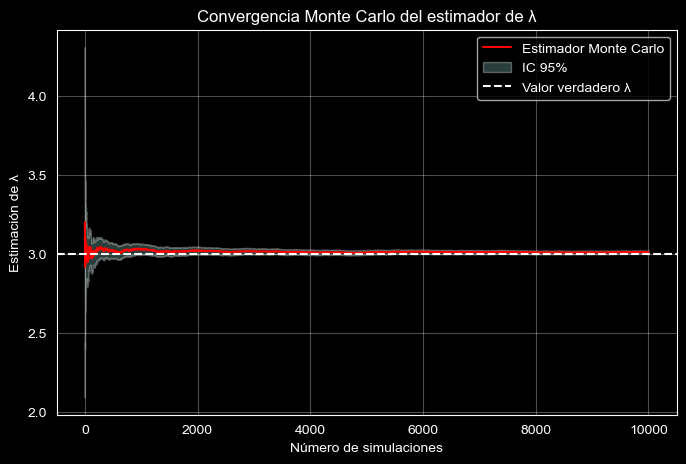

Estimador: 3.01 
Intervalo de Confianza: (3.0,3.021)


In [4]:
lam_hat , lower, upper = poi_pro.monte_carlo_lambda(t, n_sim=10000)
print("Estimador: {:.4} \nIntervalo de Confianza: ({:.4},{:.4})".format(lam_hat[-1].item(),lower[-1].item(),upper[-1].item()))

Simulando trayectorias: 100%|██████████| 10000/10000 [02:28<00:00, 67.54it/s]
C:\Users\Academica\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


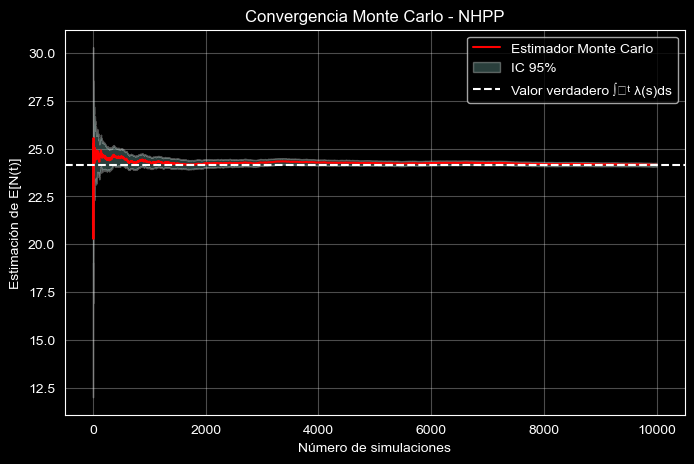

Estimador: 24.15 
Intervalo de Confianza: (24.05,24.25)


In [5]:
# Parámetros
t = 12.0
n = 100 
def lam1(x):
    return 2 + math.sin(x)

nh_poi_pro = NonHomogeneousPoissonProcess(lam1)

lam_hat , lower, upper = nh_poi_pro.monte_carlo_lambda(t, n, n_sim=10000)
print("Estimador: {:.4} \nIntervalo de Confianza: ({:.4},{:.4})".format(lam_hat[-1].item(),lower[-1].item(),upper[-1].item()))

Simulando trayectorias: 100%|██████████| 10000/10000 [00:02<00:00, 3542.57it/s]


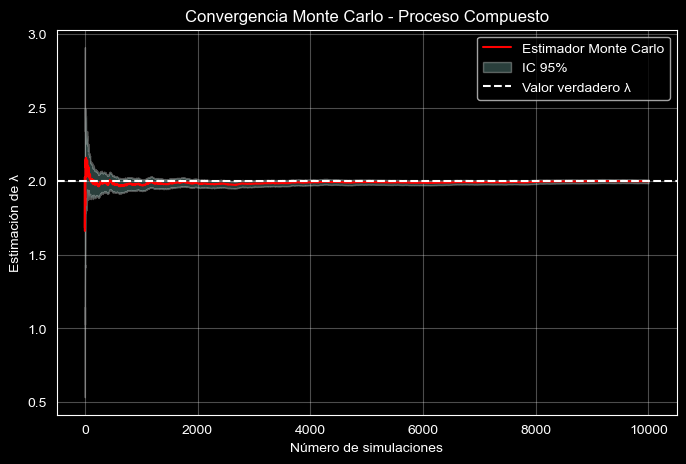

Estimador: 2.0 
Intervalo de Confianza: (1.987,2.012)


In [7]:
lam = 2
t = 10
beta = 2.5

# saltos exponenciales
jump_dist = torch.distributions.Exponential(beta)

cp = CompoundPoisson(lam, jump_dist)
lam_hat , lower, upper = cp.monte_carlo_lambda(t)
print("Estimador: {:.4} \nIntervalo de Confianza: ({:.4},{:.4})".format(lam_hat[-1].item(),lower[-1].item(),upper[-1].item()))

100%|██████████| 10000/10000 [00:03<00:00, 3094.58it/s]


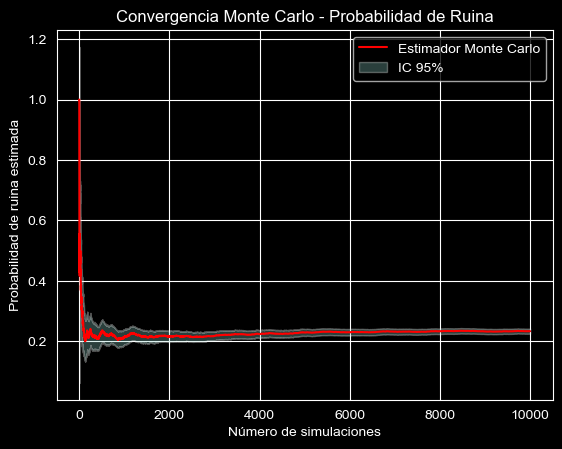

Estimador: 0.2333 
Intervalo de Confianza: (0.225,0.2416)


In [9]:

lam = 5
u = 200
beta = 1/10
i = 0.05
c = (1+i)*lam*(1/beta)
t = 12*5
n_sim = 10000


claim_dist = torch.distributions.Exponential(beta)

cl_p = CramerLundberg(u, c, lam, claim_dist)
p_hat, lower, upper = cl_p.ruin_probability_mc(t, n_sim=n_sim)
print("Estimador: {:.4} \nIntervalo de Confianza: ({:.4},{:.4})".format(p_hat,lower,upper))

100%|██████████| 10000/10000 [00:03<00:00, 2866.08it/s]


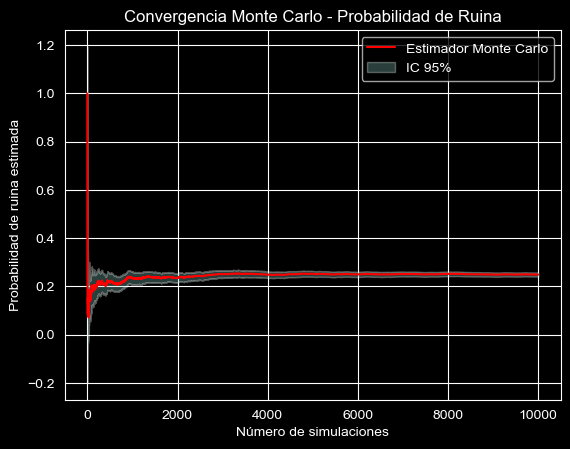

Estimador: 0.2491 
Intervalo de Confianza: (0.2406,0.2576)


In [10]:
lam = 5
u = 200
beta = 1/10
alpha = 2
i = 0.1
c = (1+i)*lam*(alpha/beta)
t = 12*5
n_sim = 10000


claim_dist = torch.distributions.Gamma(alpha,beta)

cl_p = CramerLundberg(u, c, lam, claim_dist)

p_hat, lower, upper = cl_p.ruin_probability_mc(t, n_sim=n_sim)
print("Estimador: {:.4} \nIntervalo de Confianza: ({:.4},{:.4})".format(p_hat, lower, upper))

100%|██████████| 10000/10000 [00:03<00:00, 2757.49it/s]


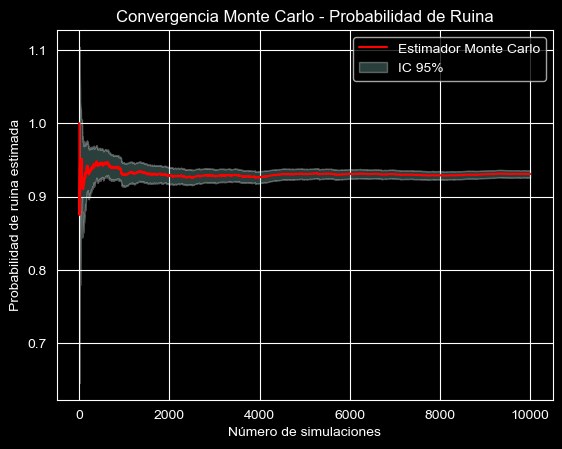

Estimador: 0.9308 
Intervalo de Confianza: (0.9258,0.9358)


In [11]:
lam = 5
u = 200
beta = 1/10
alpha = 2
i = -0.1
c = (1+i)*lam*(alpha/beta)
t = 12*5
n_sim = 10000

# saltos exponenciales
claim_dist = torch.distributions.Gamma(alpha,beta)

cl_p = CramerLundberg(u, c, lam, claim_dist)

p_hat, lower, upper = cl_p.ruin_probability_mc(t, n_sim=n_sim)
print("Estimador: {:.4} \nIntervalo de Confianza: ({:.4},{:.4})".format(p_hat, lower, upper))

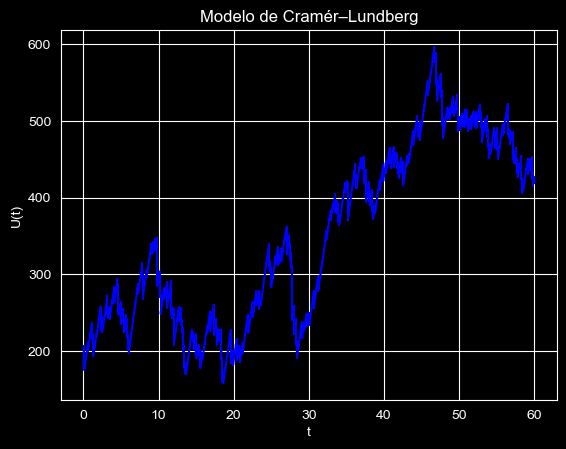

In [12]:
alphas = [2.0,8.0]
betas = [2.0,0.5]
gamma1 = torch.distributions.Gamma(concentration=alphas[0], rate=betas[0])
gamma2 = torch.distributions.Gamma(concentration=alphas[1], rate=betas[1])

densities = [gamma1,gamma2]
weights = torch.Tensor([0.6,0.4])
lam = 10
u = 200
beta = 1/10
alpha = 2
i = 0.08
c = (1+i)*lam*((weights[0]*alphas[0]/betas[0])+weights[1]*alphas[1]/betas[1])
t = 12*5
n_sim = 10000
# saltos exponenciales
claim_dist = MixtureDistribution(weights,densities)

cl_p = CramerLundberg(u, c, lam, claim_dist)
cl_p.plot(t,linestyle="-")

100%|██████████| 10000/10000 [00:06<00:00, 1526.50it/s]


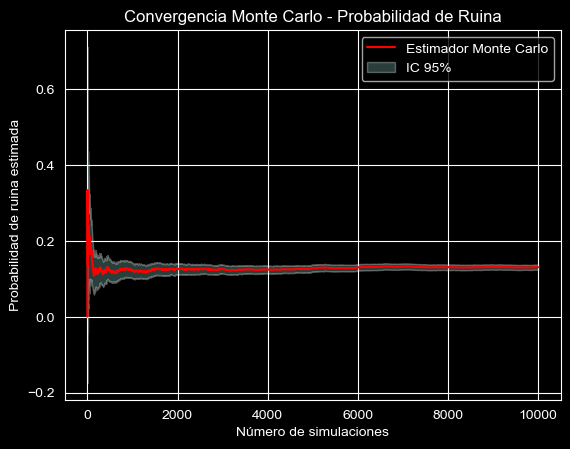

Estimador: 0.1305 
Intervalo de Confianza: (0.1239,0.1371)


In [13]:
p_hat, lower, upper = cl_p.ruin_probability_mc(t, n_sim=n_sim)
print("Estimador: {:.4} \nIntervalo de Confianza: ({:.4},{:.4})".format(p_hat, lower, upper))

Variando capital inicial u: 100%|██████████| 100/100 [03:11<00:00,  1.92s/it]


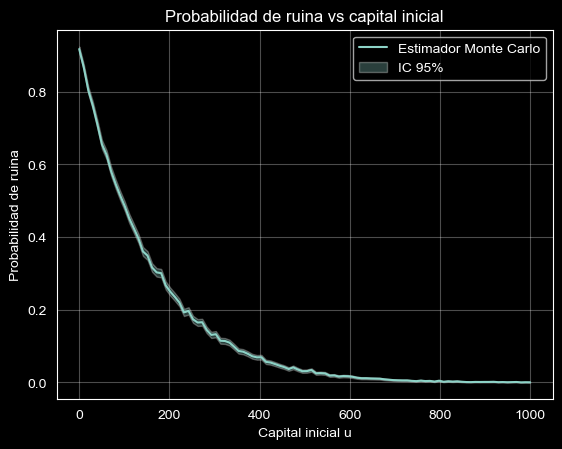

In [14]:
lam = 5
u = 200
beta = 1/10
alpha = 2
i = 0.1
c = (1+i)*lam*(alpha/beta)
t = 12*5

# saltos exponenciales
claim_dist = torch.distributions.Gamma(alpha,beta)

cl_p = CramerLundberg(u, c, lam, claim_dist)

u_vals = torch.linspace(0,1000,100)
cl_p.ruin_vs_u(u_vals,t,6000)

Variando c: 100%|██████████| 100/100 [03:18<00:00,  1.98s/it]


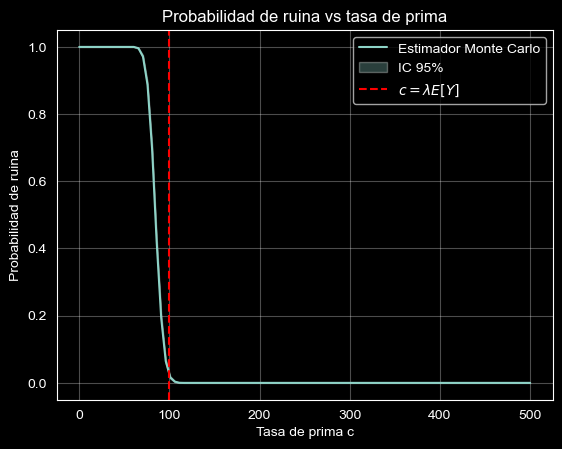

In [16]:
c_vals = torch.linspace(0,500,100)
cl_p.ruin_vs_c(c_vals,t,6000)

Variando horizonte T: 100%|██████████| 200/200 [12:16<00:00,  3.68s/it]


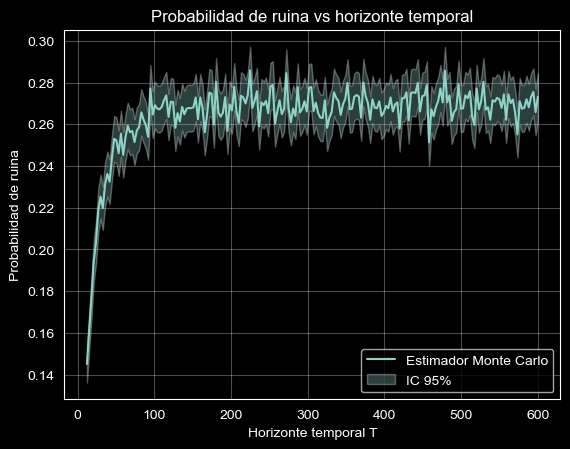

In [25]:
lam = 5
u = 200
beta = 1/10
alpha = 2
i = 0.1
c = (1+i)*lam*(alpha/beta)
t = 12*5

# saltos exponenciales
claim_dist = torch.distributions.Gamma(alpha,beta)

cl_p = CramerLundberg(u, c, lam, claim_dist)
T_vals = torch.linspace(12,12*50,200)
cl_p.ruin_vs_T(T_vals,6000)